# 300 — scRNA-seq SCT Pearson Residuals — Gaussian Decoder K-Sweep

**Input:** SCTransformed Pearson residuals (HVGs only) from tumor-only filtered cells  
**Samples:** PDX_02 or BCK_44 — set `sample:` in `configs/sct_gaussian_k_sweep.yaml`  
**Decoder:** Gaussian NLL — appropriate for continuous, approximately Gaussian residuals  

Pipeline:
1. Read `scale.data` (Pearson residuals) from `{sample}.RNA.SCT_tumor.h5seurat` via h5py
2. Select top `hvg.n_top_genes` genes by SCTransform `residual_variance` (Seurat's own HVG ranking)
3. Save HVG-subset AnnData to `data/{sample}_sct_pearson_residuals_hvg.h5ad`
4. Run Gaussian AE K-sweep over `k_values` × `seeds`
5. Diagnostic plots and automated K recommendation


In [1]:
from pathlib import Path
import sys


def _find_repo_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for path in candidates:
        if (path / 'pyproject.toml').exists() and (path / 'src' / 'cytof_archetypes').exists():
            return path
    fallback = Path('/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv')
    if (fallback / 'src' / 'cytof_archetypes').exists():
        return fallback
    raise RuntimeError('Could not locate repository root')


REPO_ROOT = _find_repo_root()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

print('Repo root:', REPO_ROOT)

Repo root: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv


## Step 1 — Load Config and Build Sample-Specific Paths

Edit `configs/sct_gaussian_k_sweep.yaml` and set `sample: "PDX_02"` or `sample: "BCK_44"`.

In [2]:
import copy
import json
import yaml
import h5py
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

from cytof_archetypes.config import load_config
from cytof_archetypes.training import train_from_config

CONFIG_PATH = REPO_ROOT / 'configs' / 'sct_gaussian_k_sweep.yaml'
assert CONFIG_PATH.exists(), f'Missing config: {CONFIG_PATH}'

with CONFIG_PATH.open('r', encoding='utf-8') as f:
    nb_cfg = yaml.safe_load(f)

SAMPLE        = str(nb_cfg['sample'])                    # 'PDX_02' or 'BCK_44'
H5SEURAT_DIR  = Path(nb_cfg['data']['h5seurat_dir'])
H5SEURAT_PATH = H5SEURAT_DIR / f'{SAMPLE}.RNA.SCT_tumor.h5seurat'
N_TOP_HVG     = int(nb_cfg.get('hvg', {}).get('n_top_genes', 3000))

PROCESSED_H5AD   = REPO_ROOT / 'data' / f'{SAMPLE}_sct_pearson_residuals_hvg.h5ad'
SWEEP_RUNS_DIR   = REPO_ROOT / 'outputs' / f'{SAMPLE}_sct_gaussian_k_sweep' / 'runs'
SWEEP_OUTPUT_ROOT = SWEEP_RUNS_DIR.parent

assert H5SEURAT_PATH.exists(), (
    f'h5seurat not found: {H5SEURAT_PATH}\n'
    f'Valid sample names: PDX_02, BCK_44'
)

print(f'Sample          : {SAMPLE}')
print(f'h5seurat        : {H5SEURAT_PATH}')
print(f'N top HVGs      : {N_TOP_HVG}')
print(f'Processed H5AD  : {PROCESSED_H5AD}')
print(f'Sweep runs dir  : {SWEEP_RUNS_DIR}')

Sample          : PDX_02
h5seurat        : /Users/ronguy/Dropbox/Work/CyTOF/SingleCell/MOme_MPGMP/MultiOme/Output/PDX_02.RNA.SCT_tumor.h5seurat
N top HVGs      : 3000
Processed H5AD  : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/PDX_02_sct_pearson_residuals_hvg.h5ad
Sweep runs dir  : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/PDX_02_sct_gaussian_k_sweep/runs


## Step 2 — Extract SCT Pearson Residuals (HVGs only) from h5seurat

Reads `scale.data` (cells × genes) from the Seurat h5seurat file, then subsets to the top
`hvg.n_top_genes` genes ranked by `residual_variance` — the same criterion Seurat uses
internally to select variable features after `SCTransform()`.

Set `FORCE_REGENERATE = True` to re-extract even if the H5AD already exists.

In [3]:
FORCE_REGENERATE = False

PROCESSED_H5AD.parent.mkdir(parents=True, exist_ok=True)

if PROCESSED_H5AD.exists() and not FORCE_REGENERATE:
    print(f'Loading existing processed H5AD: {PROCESSED_H5AD}')
    adata = ad.read_h5ad(PROCESSED_H5AD)
else:
    print(f'Reading from {H5SEURAT_PATH} ...')
    with h5py.File(H5SEURAT_PATH, 'r') as f:
        cell_names = f['cell.names'][:].astype(str)
        scale_data = f['assays/SCT/scale.data'][:].astype(np.float32)   # (cells, genes)

        # Gene names for scale.data
        for key in ('assays/SCT/scaled.features', 'assays/SCT/scale.data.features',
                    'assays/SCT/features'):
            if key in f:
                gene_names = f[key][:].astype(str)
                break

        # SCTransform residual_variance — Seurat's own HVG ranking criterion
        rv_path = 'assays/SCT/SCTModel.list/model1/feature.attributes/residual_variance'
        residual_variance = f[rv_path][:].astype(np.float64)

    print(f'  scale.data shape in file : {scale_data.shape}')

    # Ensure (cells × genes) orientation
    if scale_data.shape[0] == len(cell_names) and scale_data.shape[1] == len(gene_names):
        X_full = scale_data
    elif scale_data.shape[0] == len(gene_names) and scale_data.shape[1] == len(cell_names):
        X_full = scale_data.T
        print('  Transposed to (cells × genes)')
    else:
        raise ValueError(
            f'scale.data shape {scale_data.shape} inconsistent with '
            f'{len(cell_names)} cells and {len(gene_names)} genes'
        )

    # Select top N HVGs by residual_variance
    n_select = min(N_TOP_HVG, len(gene_names))
    hvg_idx  = np.argsort(residual_variance)[::-1][:n_select]
    hvg_idx  = np.sort(hvg_idx)                      # preserve original gene order

    X          = X_full[:, hvg_idx]
    hvg_names  = gene_names[hvg_idx]
    hvg_rv     = residual_variance[hvg_idx]

    print(f'  Genes: {len(gene_names)} total → {len(hvg_names)} HVGs selected')
    print(f'  residual_variance range of selected HVGs: '
          f'[{hvg_rv.min():.3f}, {hvg_rv.max():.3f}]')

    obs = pd.DataFrame({'cell_id': cell_names}, index=cell_names)
    var = pd.DataFrame({'residual_variance': hvg_rv}, index=hvg_names)
    var.index.name = 'gene'

    adata = ad.AnnData(X=X, obs=obs, var=var)
    adata.write_h5ad(PROCESSED_H5AD)
    print(f'  Saved: {PROCESSED_H5AD}')

print(f'\nadata shape : {adata.shape}  (cells × HVGs)')
print(f'X range     : [{float(adata.X.min()):.3f}, {float(adata.X.max()):.3f}]')
print(f'X mean      : {float(adata.X.mean()):.4f}')
print(f'X std       : {float(adata.X.std()):.4f}')

Reading from /Users/ronguy/Dropbox/Work/CyTOF/SingleCell/MOme_MPGMP/MultiOme/Output/PDX_02.RNA.SCT_tumor.h5seurat ...
  scale.data shape in file : (5774, 26476)
  Genes: 26476 total → 3000 HVGs selected
  residual_variance range of selected HVGs: [1.155, 123.827]
  Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/PDX_02_sct_pearson_residuals_hvg.h5ad

adata shape : (5774, 3000)  (cells × HVGs)
X range     : [-9.838, 14.648]
X mean      : -0.0000
X std       : 1.3446


## Step 2b — Quick QC: Distribution of Pearson Residuals

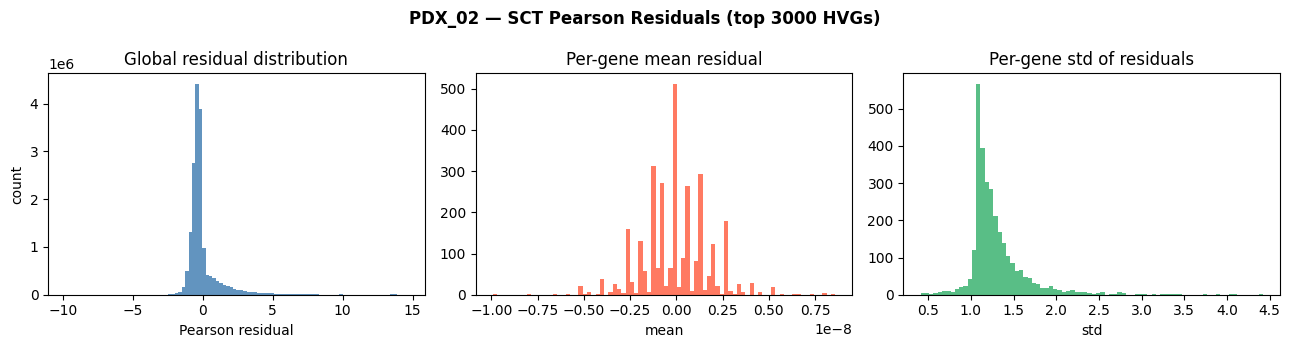

Top 10 HVGs by residual_variance:


,residual_variance
gene,
MUC19,123.827300
LRP1B,93.806848
CNTN5,65.627918
ENSG00000251574,64.667521
IGFBP5,60.010788
MGP,58.867822
LINC02505,53.732643
SCGB1B2P,46.010243
CADM2,43.851156


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
fig.suptitle(f'{SAMPLE} — SCT Pearson Residuals (top {N_TOP_HVG} HVGs)', fontsize=12, fontweight='bold')

flat = adata.X.ravel()
axes[0].hist(flat[np.isfinite(flat)], bins=100, color='steelblue', alpha=0.85)
axes[0].set_title('Global residual distribution')
axes[0].set_xlabel('Pearson residual')
axes[0].set_ylabel('count')

gene_means = adata.X.mean(axis=0)
axes[1].hist(gene_means, bins=80, color='tomato', alpha=0.85)
axes[1].set_title('Per-gene mean residual')
axes[1].set_xlabel('mean')

gene_stds = adata.X.std(axis=0)
axes[2].hist(gene_stds, bins=80, color='mediumseagreen', alpha=0.85)
axes[2].set_title('Per-gene std of residuals')
axes[2].set_xlabel('std')

plt.tight_layout()
plt.show()

if 'residual_variance' in adata.var.columns:
    rv = adata.var['residual_variance'].to_numpy()
    print(f'Top 10 HVGs by residual_variance:')
    top10 = adata.var['residual_variance'].sort_values(ascending=False).head(10)
    display(top10.to_frame())

## Step 3 — Run Gaussian AE K-Sweep

Pearson residuals are used as both encoder input and decoder target.  
`preprocessing.normalization: none` — SCT already standardizes to ~N(0,1) per gene.

**Note on loss scale:** The Gaussian NLL is *summed* over all HVGs per cell, so with
~3000 genes the reported loss will be on the order of 2000–4000. This is expected —
the per-gene contribution at perfect reconstruction is `0.5 * log(2π) ≈ 0.92`, giving
a floor of ~2750 for 3000 genes. Compare across K values and seeds, not against CyTOF runs.

Set `RUN_SWEEP = True` to train. `FORCE_RERUN = True` to redo existing runs.

In [ ]:
from datetime import datetime

RUN_SWEEP   = True
FORCE_RERUN = False

base_train_cfg = load_config(CONFIG_PATH)
base_train_cfg = copy.deepcopy(base_train_cfg)

base_train_cfg['dataset']['input_path'] = str(PROCESSED_H5AD)
base_train_cfg['output']['base_dir']    = str(SWEEP_RUNS_DIR)

k_values = [int(k) for k in nb_cfg.get('sweep', {}).get('k_values', [4, 5, 6, 7, 8])]
seeds    = [int(s) for s in nb_cfg.get('sweep', {}).get('seeds',    [42, 123, 456])]

SWEEP_RUNS_DIR.mkdir(parents=True, exist_ok=True)
SWEEP_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f'Sample  : {SAMPLE}  |  HVGs: {adata.n_vars}')
print('K values:', k_values)
print('Seeds   :', seeds)
print('Runs dir:', SWEEP_RUNS_DIR)

run_manifest_rows = []
for k in k_values:
    for sd in seeds:
        run_name = f'k{k}_seed{sd}'
        run_dir  = SWEEP_RUNS_DIR / run_name
        t_start  = datetime.now().isoformat(timespec='seconds')

        if run_dir.exists() and not FORCE_RERUN:
            status = 'skipped_existing'
            print(f'[skip] {run_name}')
        elif RUN_SWEEP:
            cfg_run = copy.deepcopy(base_train_cfg)
            cfg_run['seed']                          = int(sd)
            cfg_run['model']['n_archetypes']         = int(k)
            cfg_run['output']['run_name']            = run_name
            cfg_run['training']['progress_bar_desc'] = f'{SAMPLE}-gauss'
            print(f'[run ] {run_name}')
            out_dir = train_from_config(cfg_run)
            run_dir = Path(out_dir)
            status  = 'completed'
        else:
            status = 'not_run'

        run_manifest_rows.append({
            'k': int(k), 'seed': int(sd), 'run_name': run_name,
            'run_dir': str(run_dir), 'status': status, 'timestamp': t_start,
        })

manifest_df   = pd.DataFrame(run_manifest_rows)
manifest_path = SWEEP_OUTPUT_ROOT / 'sweep_manifest.csv'
manifest_df.to_csv(manifest_path, index=False)
print('Manifest saved:', manifest_path)
display(manifest_df)

[2026-04-13 09:36:16] INFO cytof_archetypes - Run directory: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/PDX_02_sct_gaussian_k_sweep/runs/k4_seed42


Sample  : PDX_02  |  HVGs: 3000
K values: [4, 5, 6, 7, 8]
Seeds   : [42, 123, 456]
Runs dir: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/PDX_02_sct_gaussian_k_sweep/runs
[run ] k4_seed42


[2026-04-13 09:36:16] INFO cytof_archetypes - model decoder_family=gaussian total_params=1626692 trainable_params=1626692 frozen_params=0



=== Model Architecture ===
ProbabilisticArchetypalAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3000, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=4, bias=True)
  )
)

=== Model Parameters ===
decoder_family: gaussian
total_params: 1,626,692
trainable_params: 1,626,692
frozen_params: 0
parameter_tensors:
  - archetype_means: shape=(4, 3000), count=12,000, requires_grad=True
  - archetype_logvars: shape=(4, 3000), count=12,000, requires_grad=True
  - encoder.0.weight: shape=(512, 3000), count=1,536,000, requires_grad=True
  - encoder.0.bias: shape=(512,), count=512, requires_grad=True
  - encoder.3.weight: shape=(128, 512), count=65,536, requires_grad=True
  - encoder.3.bias: shape=(128,), count=128, requires_grad=True
  - encoder.6.weight: shape=(4, 128), count=512, 

PDX_02-gauss [k4_seed42]:   7%|███▎                                           | 354/5000 [01:10<15:21,  5.04epoch/s, train=4771.3374, val=4777.3716, best=4777.3716]

## Step 4 — Load Sweep Outputs and Compute Per-Run Metrics

In [ ]:
from itertools import combinations
from scipy.optimize import linear_sum_assignment

ASSIGN_THRESH       = 0.25
ACTIVE_USAGE_FACTOR = 0.50


def _safe_read_json(path):
    if not path.exists():
        return {}
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def _read_weights(run_dir):
    for name in ['cell_weights_val.csv', 'cell_weights_test.csv', 'cell_weights_train.csv']:
        p = run_dir / 'weights' / name
        if p.exists():
            wdf  = pd.read_csv(p)
            cols = [c for c in wdf.columns if c.startswith('w_')]
            if cols:
                return wdf[cols].to_numpy(dtype=np.float32)
    return None


def _read_archetype_fractions(run_dir):
    p = run_dir / 'archetypes' / 'archetype_gene_fractions.csv'
    return pd.read_csv(p, index_col=0) if p.exists() else None


def _load_run(k, seed):
    run_dir   = SWEEP_RUNS_DIR / f'k{k}_seed{seed}'
    hist_path = run_dir / 'training_log.csv'
    frac_df   = _read_archetype_fractions(run_dir)
    W         = _read_weights(run_dir)
    if not (run_dir.exists() and hist_path.exists() and frac_df is not None and W is not None):
        return None
    return {'k': int(k), 'seed': int(seed), 'run_dir': run_dir,
            'hist': pd.read_csv(hist_path), 'fractions': frac_df, 'W': W,
            'metrics_val': _safe_read_json(run_dir / 'metrics' / 'val_metrics.json')}


def _run_metrics(run):
    k, W, F = run['k'], run['W'], run['fractions'].to_numpy(dtype=np.float32)
    hist = run['hist']
    for col in ('val_recon', 'val_nll', 'val_loss'):
        if col in hist.columns:
            best_val = float(hist[col].min())
            break
    else:
        best_val = float('nan')
    W_safe      = np.clip(W, 1e-9, 1.0)
    entropy     = -(W_safe * np.log(W_safe)).sum(axis=1)
    effective_k = float(np.exp(entropy.mean()))
    usage       = W.mean(axis=0)
    n_active    = int((usage >= ACTIVE_USAGE_FACTOR / k).sum())
    dvals       = [np.linalg.norm(F[i] - F[j]) for i, j in combinations(range(F.shape[0]), 2)] if F.shape[0] > 1 else [0.0]
    return {
        'k': k, 'seed': run['seed'], 'best_val_recon': best_val,
        'n_epochs': len(hist), 'n_active': n_active,
        'active_frac': n_active / k, 'effective_k': effective_k,
        'effective_k_frac': effective_k / k, 'diversity': float(np.mean(dvals)),
        'assign_frac': float((W.max(axis=1) >= ASSIGN_THRESH).mean()),
        'mean_entropy': float(entropy.mean()),
    }


def _cross_seed_stability(runs_k):
    if len(runs_k) < 2:
        return float('nan')
    sims = []
    for r1, r2 in combinations(runs_k, 2):
        A = r1['fractions'].to_numpy(dtype=np.float32)
        B = r2['fractions'].to_numpy(dtype=np.float32)
        A /= np.linalg.norm(A, axis=1, keepdims=True) + 1e-9
        B /= np.linalg.norm(B, axis=1, keepdims=True) + 1e-9
        ri, ci = linear_sum_assignment(1.0 - A @ B.T)
        sims.append(float((A @ B.T)[ri, ci].mean()))
    return float(np.mean(sims))


all_runs, rows = {}, []
for k in k_values:
    runs_k = [r for sd in seeds if (r := _load_run(k, sd)) is not None]
    all_runs[k] = runs_k
    rows.extend([_run_metrics(r) for r in runs_k])
    print(f'K={k}: loaded {len(runs_k)} run(s)')

metrics_df = pd.DataFrame(rows)
if metrics_df.empty:
    raise RuntimeError('No completed runs found — set RUN_SWEEP=True in Step 3.')

print('\nPer-run metrics:')
display(metrics_df.sort_values(['k', 'seed']).round(4))

In [ ]:
stability_df = pd.DataFrame(
    [{'k': k, 'cross_seed_stability': _cross_seed_stability(runs)} for k, runs in all_runs.items()]
)

agg = (
    metrics_df.groupby('k', as_index=False)
    .agg(
        best_val_recon_mean=('best_val_recon', 'mean'),
        best_val_recon_std=('best_val_recon', 'std'),
        active_frac_mean=('active_frac', 'mean'),
        effective_k_mean=('effective_k', 'mean'),
        effective_k_frac_mean=('effective_k_frac', 'mean'),
        diversity_mean=('diversity', 'mean'),
        assign_frac_mean=('assign_frac', 'mean'),
        n_seeds=('seed', 'count'),
    )
    .merge(stability_df, on='k', how='left')
)

summary_path = SWEEP_OUTPUT_ROOT / 'k_sweep_summary.csv'
agg.to_csv(summary_path, index=False)
print('Saved summary:', summary_path)
display(agg.round(4))

## Step 5 — Diagnostic Plots

In [ ]:
import matplotlib.ticker as mticker

ks  = agg['k'].to_numpy()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(f'{SAMPLE} — SCT Gaussian K-Selection Diagnostics', fontsize=14, fontweight='bold')


def _plot(ax, col, col_std=None, color='steelblue', ylabel='', title=''):
    y = agg[col].to_numpy()
    ax.plot(ks, y, 'o-', color=color, linewidth=2, markersize=6)
    if col_std and col_std in agg.columns:
        e = agg[col_std].fillna(0).to_numpy()
        ax.fill_between(ks, y - e, y + e, color=color, alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel('K')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))


_plot(axes[0, 0], 'best_val_recon_mean', 'best_val_recon_std',
      'steelblue', 'Gaussian NLL', 'Val Reconstruction Loss')
_plot(axes[0, 1], 'active_frac_mean', color='tomato',
      ylabel='Fraction active', title='Active Archetype Fraction')
axes[0, 1].axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[0, 1].set_ylim(0, 1.1)

axes[0, 2].plot(ks, ks, '--', color='gray', linewidth=1, label='ideal')
_plot(axes[0, 2], 'effective_k_mean', color='mediumseagreen',
      ylabel='Effective K', title='Effective K vs K')
axes[0, 2].legend(fontsize=8)

_plot(axes[1, 0], 'diversity_mean', color='darkorchid',
      ylabel='Mean pairwise L2', title='Archetype Diversity')

ax = axes[1, 1]
if agg['cross_seed_stability'].notna().any():
    ax.plot(ks, agg['cross_seed_stability'].to_numpy(), 'o-',
            color='darkorange', linewidth=2, markersize=6)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Mean cosine similarity')
else:
    ax.text(0.5, 0.5, 'Only 1 seed per K', ha='center', va='center',
            transform=ax.transAxes, fontsize=10, color='gray')
ax.set_title('Cross-Seed Stability')
ax.set_xlabel('K')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

_plot(axes[1, 2], 'assign_frac_mean', color='sienna',
      ylabel='Fraction assigned', title=f'Assignment (max_w >= {ASSIGN_THRESH})')
axes[1, 2].set_ylim(0, 1.1)

fig.tight_layout()
plt.show()

## Step 6 — Automated K Recommendation

In [ ]:
import warnings

rec    = agg.sort_values('k').reset_index(drop=True).copy()
losses = rec['best_val_recon_mean'].to_numpy(dtype=float)
ks_num = rec['k'].to_numpy(dtype=float)

if len(losses) > 1:
    dloss    = -np.diff(losses, prepend=losses[0])
    dk       = np.diff(ks_num, prepend=ks_num[0])
    dk[dk == 0] = 1.0
    marginal = np.maximum(dloss / dk, 0)
    rec['score_loss'] = marginal / (marginal.max() + 1e-12)
else:
    rec['score_loss'] = 1.0

n_active = rec['active_frac_mean'] * rec['k']
rec['score_active']    = (n_active / (n_active.max() + 1e-12)).clip(0, 1)
rec['score_eff_k']     = rec['effective_k_frac_mean'].clip(0, 1)
rec['score_stability'] = rec['cross_seed_stability'].fillna(0.5).clip(0, 1)

DEAD_FRAC_LIMIT = 0.30
dead_penalty = np.where(
    rec['active_frac_mean'] < (1.0 - DEAD_FRAC_LIMIT),
    rec['active_frac_mean'] / (1.0 - DEAD_FRAC_LIMIT),
    1.0,
)
rec['composite_score'] = (
    (0.30 * rec['score_loss'] + 0.35 * rec['score_active']
     + 0.25 * rec['score_eff_k'] + 0.10 * rec['score_stability'])
    * dead_penalty
)

display(
    rec[['k', 'best_val_recon_mean', 'active_frac_mean', 'effective_k_frac_mean',
         'cross_seed_stability', 'score_loss', 'score_active', 'composite_score']]
    .sort_values('composite_score', ascending=False).round(4)
)

best_k = int(rec.loc[rec['composite_score'].idxmax(), 'k'])
print(f'>>> Recommended K: {best_k} <<< (sample={SAMPLE})')

br = rec[rec['k'] == best_k].iloc[0]
n_dead = round((1.0 - br['active_frac_mean']) * best_k)
if n_dead > 0:
    warnings.warn(f'K={best_k} has ~{n_dead} under-used archetype(s).')
if br['effective_k_frac_mean'] < 0.5:
    warnings.warn(f'K={best_k} effective utilisation is low ({br["effective_k_frac_mean"]:.1%}).')

## Step 7 — Inspect Best-K Archetype Gene Loadings

In [ ]:
best_runs = all_runs.get(best_k, [])
if not best_runs:
    print(f'No runs found for best K={best_k}')
else:
    def _val_loss(r):
        h = r['hist']
        for col in ('val_recon', 'val_nll', 'val_loss'):
            if col in h.columns:
                return float(h[col].min())
        return float('inf')

    best_run = min(best_runs, key=_val_loss)
    frac_df  = best_run['fractions'].copy()

    print(f'Best-K: K={best_k}, seed={best_run["seed"]} (sample={SAMPLE})')
    print('-' * 100)
    for arch in frac_df.index:
        top     = frac_df.loc[arch].sort_values(ascending=False).head(10)
        top_str = ', '.join([f'{g}:{v:.3f}' for g, v in top.items()])
        print(f'{arch}: {top_str}')

In [ ]:
if best_runs:
    frac_df = best_run['fractions'].copy()
    frac_df.index = [f'A{i:02d}' for i in range(frac_df.shape[0])]

    top_var_genes = frac_df.var(axis=0).sort_values(ascending=False).head(40).index
    mat = frac_df[top_var_genes]

    fig, ax = plt.subplots(figsize=(max(10, mat.shape[1] * 0.23), max(3.8, mat.shape[0] * 0.55)))
    im = ax.imshow(mat.values, aspect='auto', cmap='viridis')
    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels(mat.index, fontsize=9)
    ax.set_title(
        f'{SAMPLE} — Archetype Gene Fractions (top variable) — Gaussian K={best_k}',
        fontweight='bold'
    )
    plt.colorbar(im, ax=ax, shrink=0.75, label='Gene fraction')
    fig.tight_layout()
    plt.show()

## Notes

- **Input:** `{sample}.RNA.SCT_tumor.h5seurat` — SCTransform Pearson residuals, tumor-only cells
- **HVG selection:** top `hvg.n_top_genes` genes by `residual_variance` (Seurat's own criterion)
- **Decoder:** Gaussian NLL — suitable for continuous, pre-standardized residuals
- **Preprocessing:** none — SCT residuals are ~N(0,1) per gene; light clipping at ±10
- **Switch sample:** change `sample:` in `configs/sct_gaussian_k_sweep.yaml`
- **Processed H5AD:** `data/{sample}_sct_pearson_residuals_hvg.h5ad`
- **Sweep outputs:** `outputs/{sample}_sct_gaussian_k_sweep/`
